In [2]:

def brute_force_vertex_cover(G):
    n = G.number_of_nodes()
    edges = list(G.edges())
    number_of_subsets = 1 << n
    size_of_vertex_cover = n+1
    vertex_cover = []

    for mask in range(number_of_subsets):

        cover = mask_to_vertex_cover(mask, n)

        if is_vertex_cover(edges, cover):
            if len(cover) < size_of_vertex_cover:
                size_of_vertex_cover = len(cover)
                vertex_cover = cover
                
    return vertex_cover
        

In [3]:
def is_vertex_cover(edges, cover):
    for u,v in edges:
        for i in cover:
            if u == i or v == i:
                break
        else:
            return False
    return True

In [4]:
import matplotlib.pyplot as plt
import networkx as nx
def draw_graph(G, cover):

    pos = nx.spring_layout(G, seed=42)

    colors = []

    for node in G.nodes():
        if node in cover:
            colors.append("red")
        else:
            colors.append("skyblue")
    plt.figure(figsize=(7,7))

    nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=700)
    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_labels(G, pos)
    plt.title("Minimum Vertex Cover")
    plt.axis("off")
    plt.show()
    plt.close()

In [5]:
import networkx as nx

def generate_graph(n,m):
    # generate a random graph with n vertices and m edges

    G = nx.gnm_random_graph(n,m)
    
    return G



In [6]:
def mask_to_vertex_cover(mask, n):
    vertex_cover = []
    for i in range(n):
        if (mask >> i)& 1:
            vertex_cover.append(i)

    return vertex_cover
    

[0, 1, 2, 4, 5]


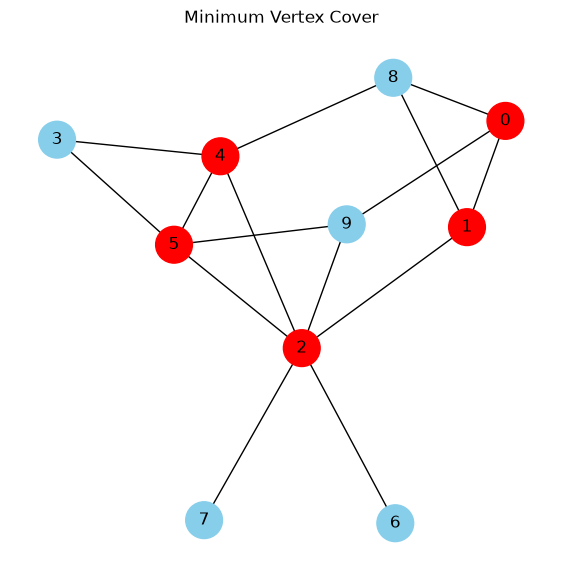

[0, 1, 4, 6, 7, 9]


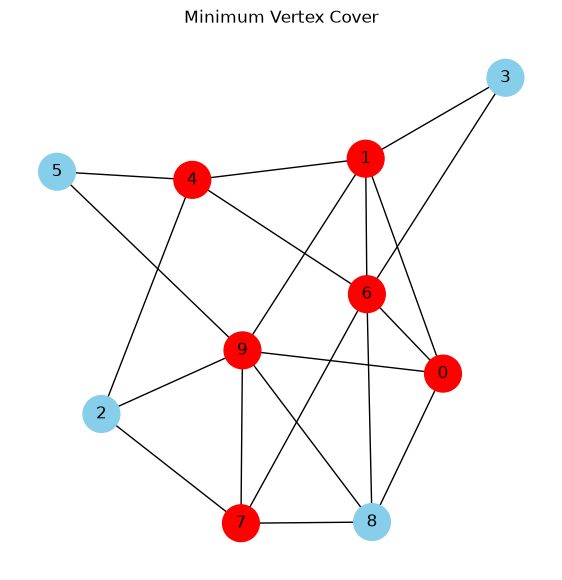

[0, 2, 3, 4, 5, 6, 7]


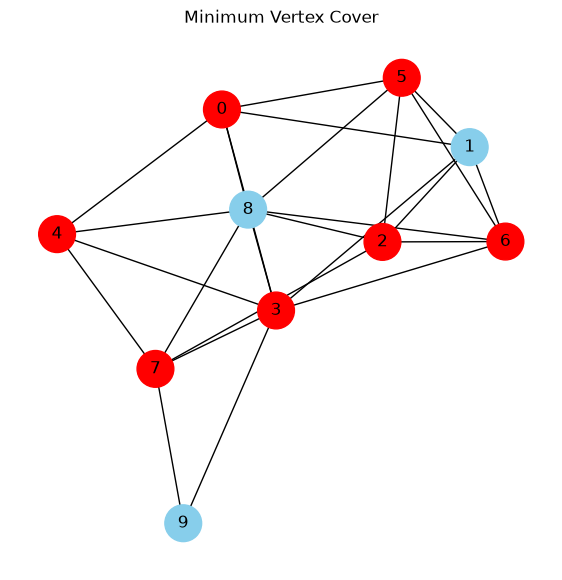

[0, 2, 3, 4, 5, 7, 9]


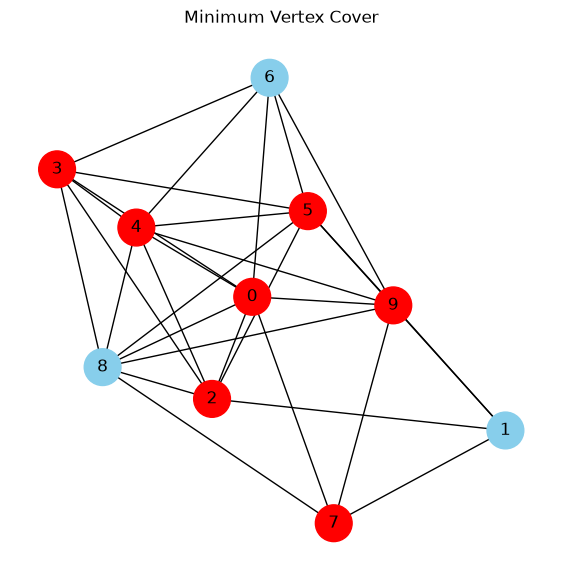

[1, 3, 4, 6, 7, 8, 9]


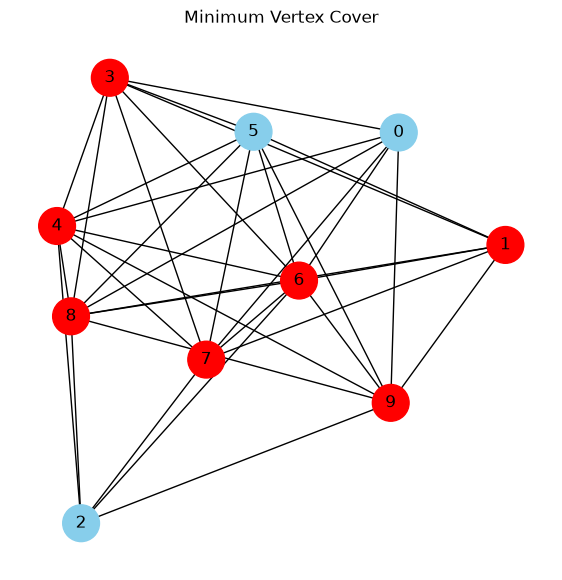

[0, 1, 2, 3, 4, 6, 7, 8]


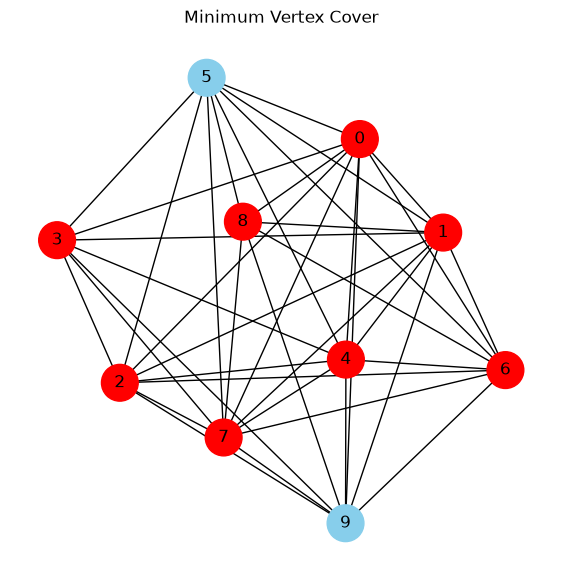

[0, 1, 2, 3, 4, 5, 6, 7, 8]


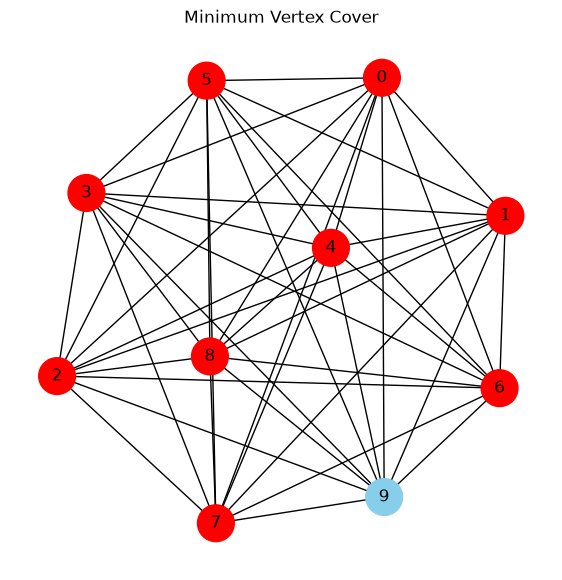

In [7]:

n = 10
for m in range(15, 46, 5):
    G = generate_graph(n,m)
    cover = brute_force_vertex_cover(G)
    print(cover)
    draw_graph(G, cover)


In [9]:
import networkx as nx
import random
def generate_graph(n,m):
    # generate a random graph with n vertices and m edges

    edges = []
    while(len(edges) < m):
        a = random.randint(0,n-1)
        b = random.randint(0,n-1)
        if a != b:
            if (a,b) in edges or (b,a) in edges:
                continue
            else:
                edges.append((a,b))
    
    for i in edges:
        print(i)
generate_graph(10,34)    

(7, 0)
(3, 2)
(5, 4)
(1, 0)
(5, 8)
(2, 9)
(9, 1)
(3, 4)
(6, 3)
(2, 5)
(9, 8)
(4, 0)
(5, 7)
(0, 5)
(3, 1)
(7, 8)
(6, 8)
(2, 4)
(9, 6)
(7, 9)
(6, 1)
(0, 8)
(9, 5)
(0, 2)
(7, 1)
(6, 2)
(3, 5)
(2, 1)
(7, 6)
(3, 0)
(4, 9)
(4, 7)
(0, 6)
(8, 3)
